# DistilBERT Layer-by-Layer Sentiment Representations

This notebook feeds rows from the Kaggle **sentiment analysis for mental health** dataset through a Hugging Face DistilBERT sentiment model and visualizes how the representation changes from the embedding output through each transformer layer.

We use `distilbert-base-uncased-finetuned-sst-2-english`, which is a DistilBERT checkpoint fine-tuned for binary positive/negative sentiment. The dataset labels here are mental-health status categories (`Anxiety`, `Depression`, `Normal`, etc.).

DistilBERT has 6 transformer layers. With `output_hidden_states=True`, Hugging Face returns 7 tensors: the embedding output plus one hidden-state tensor after each layer.

## Important runtime note

If you previously opened this notebook before the `KeyError: status` fix, restart the kernel and run from the top. The fixed sampler does **not** use `groupby(...).apply(...)`; it uses `pd.concat` over grouped samples so the `status` column is preserved across pandas versions.


## 1. Imports and configuration

In [1]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
# Allows unsupported MPS ops to fall back to CPU instead of crashing.
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("datasets/Combined Data.csv")
OUTPUT_DIR = Path("outputs/distilbert_layer_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
MAX_LENGTH = 192
# Leave as None to choose a hardware-aware default below.
BATCH_SIZE = None

# True means every non-empty dataset row is passed through DistilBERT.
# Set to False for a quick smoke test while developing the notebook.
PROCESS_ALL_ROWS = False
SMOKE_TEST_ROWS = 512
# Reuse saved layer metrics/vectors on reruns. Set True after changing model/max length/sample settings.
FORCE_RECOMPUTE = False

# Full hidden vectors are kept only for this balanced sample to make PCA and probes tractable.
VISUALIZATION_SAMPLE_PER_CLASS = 400
RANDOM_STATE = 42
# M2 Pro's GPU is usually faster in float16. The notebook auto-falls back if this causes an MPS error.
USE_FLOAT16_ON_MPS = True

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

if BATCH_SIZE is None:
    if DEVICE.type == "cuda":
        BATCH_SIZE = 128
    elif DEVICE.type == "mps":
        # Good starting point for an Apple M2 Pro. Lower to 32 if memory pressure appears.
        BATCH_SIZE = 64
    else:
        BATCH_SIZE = 16

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

mps_backend = getattr(torch.backends, "mps", None)
if mps_backend is not None:
    print(f"MPS built: {mps_backend.is_built()}; MPS available: {mps_backend.is_available()}")
print(f"Device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")
DEVICE

MPS built: True; MPS available: False
Device: cpu
Batch size: 16


device(type='cpu')

## 2. Load the dataset

In [2]:
def load_clean_dataset(path):
    loaded = pd.read_csv(path)
    loaded = loaded[["statement", "status"]].copy()
    loaded["statement"] = loaded["statement"].astype("string")
    loaded["status"] = loaded["status"].astype("string")
    loaded = loaded.dropna(subset=["statement", "status"])
    loaded["statement"] = loaded["statement"].str.strip()
    loaded = loaded[loaded["statement"] != ""].reset_index(drop=True)
    loaded["row_id"] = np.arange(len(loaded))
    return loaded


data_df = load_clean_dataset(DATA_PATH)
# Backward-compatible alias for ad hoc cells.
df = data_df

print(f"Rows after cleaning: {len(data_df):,}")
display(data_df.head())
display(data_df["status"].value_counts().rename_axis("status").to_frame("count"))

Rows after cleaning: 52,681


,statement,status,row_id
0,oh my gosh,Anxiety,0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,1
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,2
3,I've shifted my focus to something else but I'...,Anxiety,3
4,"I'm restless and restless, it's been a month n...",Anxiety,4


,count
status,
Normal,16343
Depression,15404
Suicidal,10652
Anxiety,3841
Bipolar,2777
Stress,2587
Personality disorder,1077


## 3. Load DistilBERT

The first run may download the model weights from Hugging Face. If this cell fails because `torch` or `transformers` is missing, select the project virtual environment as the notebook kernel or install the dependencies from `requirements.txt`.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
)
MODEL_DTYPE = torch.float16 if DEVICE.type == "mps" and USE_FLOAT16_ON_MPS else torch.float32
model.to(device=DEVICE, dtype=MODEL_DTYPE)
model.eval()

id2label = {int(k): v for k, v in model.config.id2label.items()}
label2id = {v.upper(): k for k, v in id2label.items()}
positive_id = label2id.get("POSITIVE", 1)
negative_id = label2id.get("NEGATIVE", 0)
layer_names = ["embeddings"] + [f"layer_{i}" for i in range(1, model.config.n_layers + 1)]

print(f"Model: {MODEL_NAME}")
print(f"Device: {DEVICE}")
print(f"Model dtype: {MODEL_DTYPE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Sentiment labels: {id2label}")
print(f"Hidden-state outputs: {len(layer_names)} -> {layer_names}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model: distilbert-base-uncased-finetuned-sst-2-english
Device: cpu
Model dtype: torch.float32
Batch size: 16
Sentiment labels: {0: 'NEGATIVE', 1: 'POSITIVE'}
Hidden-state outputs: 7 -> ['embeddings', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6']


## 4. Helper functions

For every row, we collect three layer-wise summaries:

- `positive_*` and `negative_*`: the SST-2 sentiment head applied to each layer's `[CLS]` representation.
- `delta_prev_*`: cosine distance from the previous layer's `[CLS]` representation.
- `cosine_to_embeddings_*`: cosine similarity to the original embedding output.

For visualization, we also retain the full `[CLS]` vector for a balanced sample.

In [4]:
def require_dataset_columns(frame, name="frame"):
    if "status" not in frame.columns and "status" in frame.index.names:
        frame = frame.reset_index()
    required = {"statement", "status", "row_id"}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(
            f"{name} is missing columns {sorted(missing)}. "
            "Restart the kernel and run cells from the top, or rerun the dataset-loading cell."
        )
    return frame


def balanced_sample(frame, per_class=400, random_state=42):
    frame = require_dataset_columns(frame, name="balanced_sample input")
    samples = [
        group.sample(n=min(len(group), per_class), random_state=random_state)
        for _, group in frame.groupby("status", sort=False)
    ]
    return pd.concat(samples, ignore_index=True).sort_values("row_id").reset_index(drop=True)


def classifier_logits_from_cls(cls_hidden):
    """Apply the DistilBERT sequence-classification head to any layer's CLS vector."""
    x = model.pre_classifier(cls_hidden)
    x = F.relu(x)
    x = model.dropout(x)
    return model.classifier(x)


def move_model(device, dtype):
    global DEVICE, MODEL_DTYPE, model
    DEVICE = torch.device(device)
    MODEL_DTYPE = dtype
    model.to(device=DEVICE, dtype=MODEL_DTYPE)
    model.eval()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    print(f"Runtime now using device={DEVICE}, dtype={MODEL_DTYPE}")


def encode_batch_once(texts):
    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    encoded = {key: value.to(DEVICE, non_blocking=True) for key, value in encoded.items()}
    with torch.inference_mode():
        outputs = model(**encoded, output_hidden_states=True, return_dict=True)

    # Shape: batch, layer_count, hidden_dim. The first token is DistilBERT's CLS token.
    cls_by_layer = torch.stack([state[:, 0, :] for state in outputs.hidden_states], dim=1)

    logits_by_layer = torch.stack(
        [classifier_logits_from_cls(cls_by_layer[:, layer_idx, :]) for layer_idx in range(cls_by_layer.shape[1])],
        dim=1,
    )
    probs_by_layer = logits_by_layer.float().softmax(dim=-1)

    delta_prev = torch.zeros(cls_by_layer.shape[:2], device=cls_by_layer.device)
    delta_prev[:, 1:] = 1 - F.cosine_similarity(cls_by_layer[:, 1:, :], cls_by_layer[:, :-1, :], dim=-1)

    cosine_to_embeddings = F.cosine_similarity(cls_by_layer, cls_by_layer[:, :1, :], dim=-1)

    return {
        "cls_by_layer": cls_by_layer.detach().cpu().float().numpy(),
        "probs_by_layer": probs_by_layer.detach().cpu().float().numpy(),
        "delta_prev": delta_prev.detach().cpu().float().numpy(),
        "cosine_to_embeddings": cosine_to_embeddings.detach().cpu().float().numpy(),
    }


def encode_batch(texts):
    global BATCH_SIZE
    try:
        return encode_batch_once(texts)
    except RuntimeError as err:
        message = str(err)
        if DEVICE.type == "mps" and MODEL_DTYPE == torch.float16:
            print("MPS float16 failed; retrying on MPS float32. Original error:")
            print(message[:600])
            move_model("mps", torch.float32)
            return encode_batch_once(texts)
        if DEVICE.type == "mps":
            print("MPS failed; retrying on CPU float32. Original error:")
            print(message[:600])
            move_model("cpu", torch.float32)
            BATCH_SIZE = min(BATCH_SIZE, 16)
            return encode_batch_once(texts)
        raise


def run_layer_analysis(frame, sample_ids):
    records = []
    sample_vectors = []
    sample_meta = []

    for start in tqdm(range(0, len(frame), BATCH_SIZE), desc="DistilBERT batches"):
        batch = frame.iloc[start : start + BATCH_SIZE]
        encoded = encode_batch(batch["statement"].tolist())
        probs = encoded["probs_by_layer"]
        delta_prev = encoded["delta_prev"]
        cosine_to_embeddings = encoded["cosine_to_embeddings"]

        for row_offset, row in enumerate(batch.itertuples(index=False)):
            record = {
                "row_id": int(row.row_id),
                "status": str(row.status),
                "statement_preview": str(row.statement)[:160],
            }
            for layer_idx, layer_name in enumerate(layer_names):
                record[f"negative_{layer_name}"] = float(probs[row_offset, layer_idx, negative_id])
                record[f"positive_{layer_name}"] = float(probs[row_offset, layer_idx, positive_id])
                record[f"delta_prev_{layer_name}"] = float(delta_prev[row_offset, layer_idx])
                record[f"cosine_to_embeddings_{layer_name}"] = float(cosine_to_embeddings[row_offset, layer_idx])
            records.append(record)

        in_sample = batch["row_id"].isin(sample_ids).to_numpy()
        if in_sample.any():
            sample_vectors.append(encoded["cls_by_layer"][in_sample])
            sample_meta.append(batch.loc[in_sample, ["row_id", "status", "statement"]].copy())

    metrics = pd.DataFrame.from_records(records)
    vectors = np.concatenate(sample_vectors, axis=0) if sample_vectors else np.empty((0, len(layer_names), 0))
    meta = pd.concat(sample_meta, ignore_index=True) if sample_meta else pd.DataFrame()
    return metrics, vectors, meta

## 5. Feed rows through DistilBERT

With `PROCESS_ALL_ROWS = True`, this cell feeds every cleaned row through DistilBERT. On CPU this can take a while. The full hidden vectors are retained only for the balanced visualization sample to avoid creating a multi-gigabyte notebook object.

In [5]:
source_df = globals().get("data_df", load_clean_dataset(DATA_PATH))
source_df = require_dataset_columns(source_df, name="source_df")

analysis_df = source_df.copy()
if not PROCESS_ALL_ROWS:
    analysis_df = balanced_sample(source_df, per_class=max(1, SMOKE_TEST_ROWS // source_df["status"].nunique()), random_state=RANDOM_STATE)

sample_df = balanced_sample(analysis_df, per_class=VISUALIZATION_SAMPLE_PER_CLASS, random_state=RANDOM_STATE)
sample_ids = set(sample_df["row_id"].tolist())

metrics_path = OUTPUT_DIR / "all_rows_layer_sentiment_and_drift.csv"
sample_meta_path = OUTPUT_DIR / "sample_rows.csv"
sample_vectors_path = OUTPUT_DIR / "sample_cls_vectors_by_layer.npy"
cache_metadata_path = OUTPUT_DIR / "analysis_metadata.json"

cache_metadata = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "process_all_rows": PROCESS_ALL_ROWS,
    "analysis_rows": int(len(analysis_df)),
    "visualization_sample_per_class": VISUALIZATION_SAMPLE_PER_CLASS,
    "sample_row_ids": sorted(int(row_id) for row_id in sample_ids),
    "layer_names": layer_names,
}

def cache_is_valid():
    if FORCE_RECOMPUTE:
        return False
    required_paths = [metrics_path, sample_meta_path, sample_vectors_path, cache_metadata_path]
    if not all(path.exists() for path in required_paths):
        return False
    import json
    with cache_metadata_path.open() as f:
        previous_metadata = json.load(f)
    return previous_metadata == cache_metadata

print(f"Rows to pass through DistilBERT: {len(analysis_df):,}")
print(f"Rows kept with full layer vectors for plots/probes: {len(sample_df):,}")
print(f"Device: {DEVICE}; dtype: {MODEL_DTYPE}; batch size: {BATCH_SIZE}")

if cache_is_valid():
    print("Loading cached DistilBERT layer artifacts. Set FORCE_RECOMPUTE=True to rerun encoding.")
    layer_metrics = pd.read_csv(metrics_path)
    sample_meta = pd.read_csv(sample_meta_path)
    sample_layer_vectors = np.load(sample_vectors_path)
else:
    layer_metrics, sample_layer_vectors, sample_meta = run_layer_analysis(analysis_df, sample_ids)

    layer_metrics.to_csv(metrics_path, index=False)
    sample_meta.to_csv(sample_meta_path, index=False)
    np.save(sample_vectors_path, sample_layer_vectors)
    import json
    with cache_metadata_path.open("w") as f:
        json.dump(cache_metadata, f, indent=2)

    if DEVICE.type == "mps":
        torch.mps.empty_cache()

print("Layer metrics shape:", layer_metrics.shape)
print("Sample vectors shape:", sample_layer_vectors.shape)
display(layer_metrics.head())

Rows to pass through DistilBERT: 511
Rows kept with full layer vectors for plots/probes: 511
Device: cpu; dtype: torch.float32; batch size: 16


DistilBERT batches:   0%|          | 0/32 [00:00<?, ?it/s]

Layer metrics shape: (511, 31)
Sample vectors shape: (511, 7, 768)


,row_id,status,statement_preview,negative_embeddings,positive_embeddings,delta_prev_embeddings,cosine_to_embeddings_embeddings,negative_layer_1,positive_layer_1,delta_prev_layer_1,...,delta_prev_layer_4,cosine_to_embeddings_layer_4,negative_layer_5,positive_layer_5,delta_prev_layer_5,cosine_to_embeddings_layer_5,negative_layer_6,positive_layer_6,delta_prev_layer_6,cosine_to_embeddings_layer_6
0,14,Anxiety,Sometimes it's your own thoughts that make you...,0.488663,0.511337,0.0,1.0,0.483796,0.516204,0.104656,...,0.070044,0.710497,0.525400,0.474600,0.197448,0.607582,0.537710,0.462290,0.366054,0.301964
1,179,Anxiety,Actually I'm worried. The original looks reall...,0.488663,0.511337,0.0,1.0,0.482524,0.517476,0.104982,...,0.099322,0.675843,0.982902,0.017098,0.401324,0.459823,0.997355,0.002645,0.344743,0.159517
2,211,Anxiety,I'm really nervous about choosing between bori...,0.488663,0.511337,0.0,1.0,0.483010,0.516990,0.104319,...,0.092275,0.683276,0.952688,0.047312,0.264738,0.509260,0.995804,0.004196,0.404950,0.159119
3,229,Anxiety,"When I'm done with this, why do I feel so dizz...",0.488663,0.511337,0.0,1.0,0.472436,0.527564,0.130243,...,0.087761,0.647530,0.852978,0.147022,0.280688,0.496019,0.991170,0.008830,0.392498,0.162112
4,291,Anxiety,"Now, he's always anxious every day, it feels l...",0.488663,0.511337,0.0,1.0,0.482518,0.517482,0.110002,...,0.081098,0.685430,0.875640,0.124360,0.232823,0.584620,0.986121,0.013879,0.394183,0.247984


## 6. Sentiment-head trajectory by mental-health status

Here we apply the final SST-2 sentiment head to the `[CLS]` vector from each layer. This asks: *if the sentiment head saw this layer's representation, how positive or negative would it consider the row?*

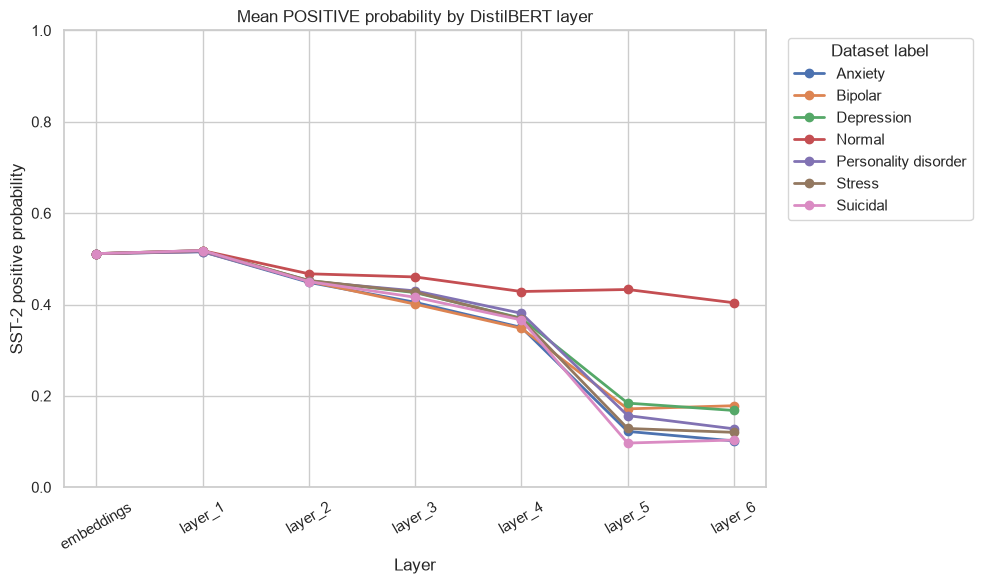

In [6]:
positive_cols = [f"positive_{name}" for name in layer_names]
positive_by_status = layer_metrics.groupby("status")[positive_cols].mean()
positive_by_status.columns = layer_names

fig, ax = plt.subplots(figsize=(10, 6))
for status, values in positive_by_status.iterrows():
    ax.plot(layer_names, values.values, marker="o", linewidth=2, label=status)

ax.set_title("Mean POSITIVE probability by DistilBERT layer")
ax.set_xlabel("Layer")
ax.set_ylabel("SST-2 positive probability")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Dataset label", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "positive_probability_trajectory_by_status.png", dpi=180, bbox_inches="tight")
plt.show()

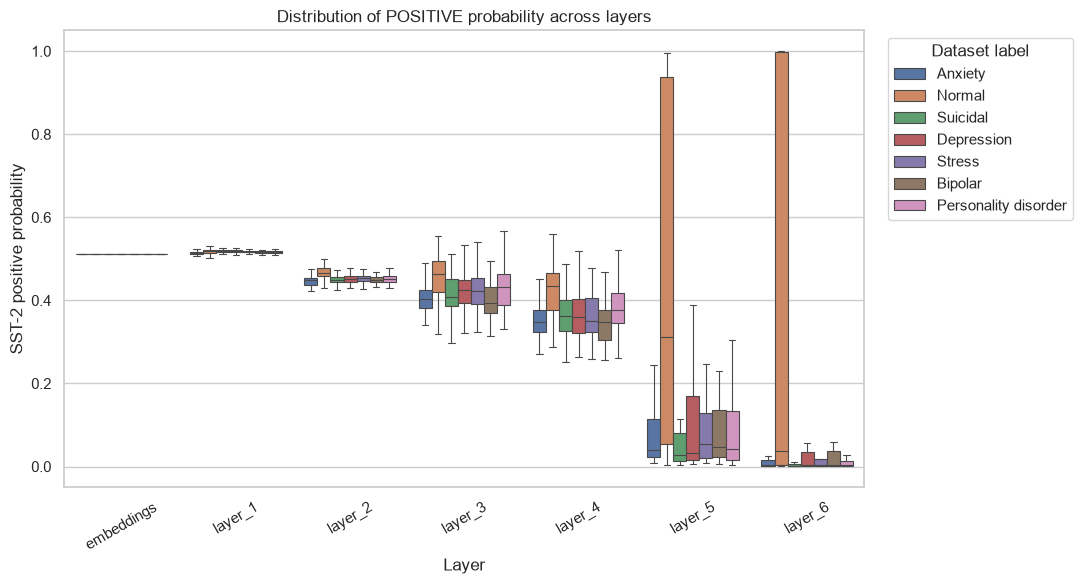

In [7]:
long_positive = layer_metrics.melt(
    id_vars=["row_id", "status"],
    value_vars=positive_cols,
    var_name="layer",
    value_name="positive_probability",
)
long_positive["layer"] = long_positive["layer"].str.replace("positive_", "", regex=False)
long_positive["layer"] = pd.Categorical(long_positive["layer"], categories=layer_names, ordered=True)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=long_positive,
    x="layer",
    y="positive_probability",
    hue="status",
    fliersize=0,
    linewidth=0.8,
    ax=ax,
)
ax.set_title("Distribution of POSITIVE probability across layers")
ax.set_xlabel("Layer")
ax.set_ylabel("SST-2 positive probability")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Dataset label", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "positive_probability_boxplot_by_layer.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Representation drift from layer to layer

`delta_prev` is cosine distance between the current layer's `[CLS]` vector and the previous layer's `[CLS]` vector. Larger values indicate a bigger representational change at that layer.

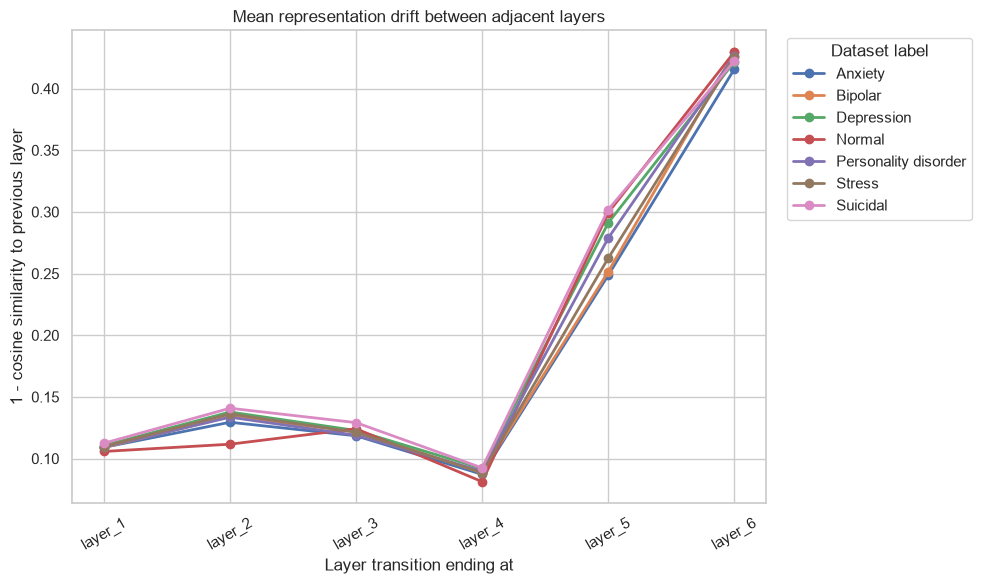

In [8]:
drift_cols = [f"delta_prev_{name}" for name in layer_names[1:]]
drift_by_status = layer_metrics.groupby("status")[drift_cols].mean()
drift_by_status.columns = layer_names[1:]

fig, ax = plt.subplots(figsize=(10, 6))
for status, values in drift_by_status.iterrows():
    ax.plot(layer_names[1:], values.values, marker="o", linewidth=2, label=status)

ax.set_title("Mean representation drift between adjacent layers")
ax.set_xlabel("Layer transition ending at")
ax.set_ylabel("1 - cosine similarity to previous layer")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Dataset label", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "representation_drift_by_status.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. PCA view of the hidden representation at each layer

The PCA is fit once on all sampled layer vectors, then each layer is plotted in the same 2D coordinate system. This makes the movement of clusters across layers visually comparable.

Explained variance ratio: [0.3293447 0.2283302]


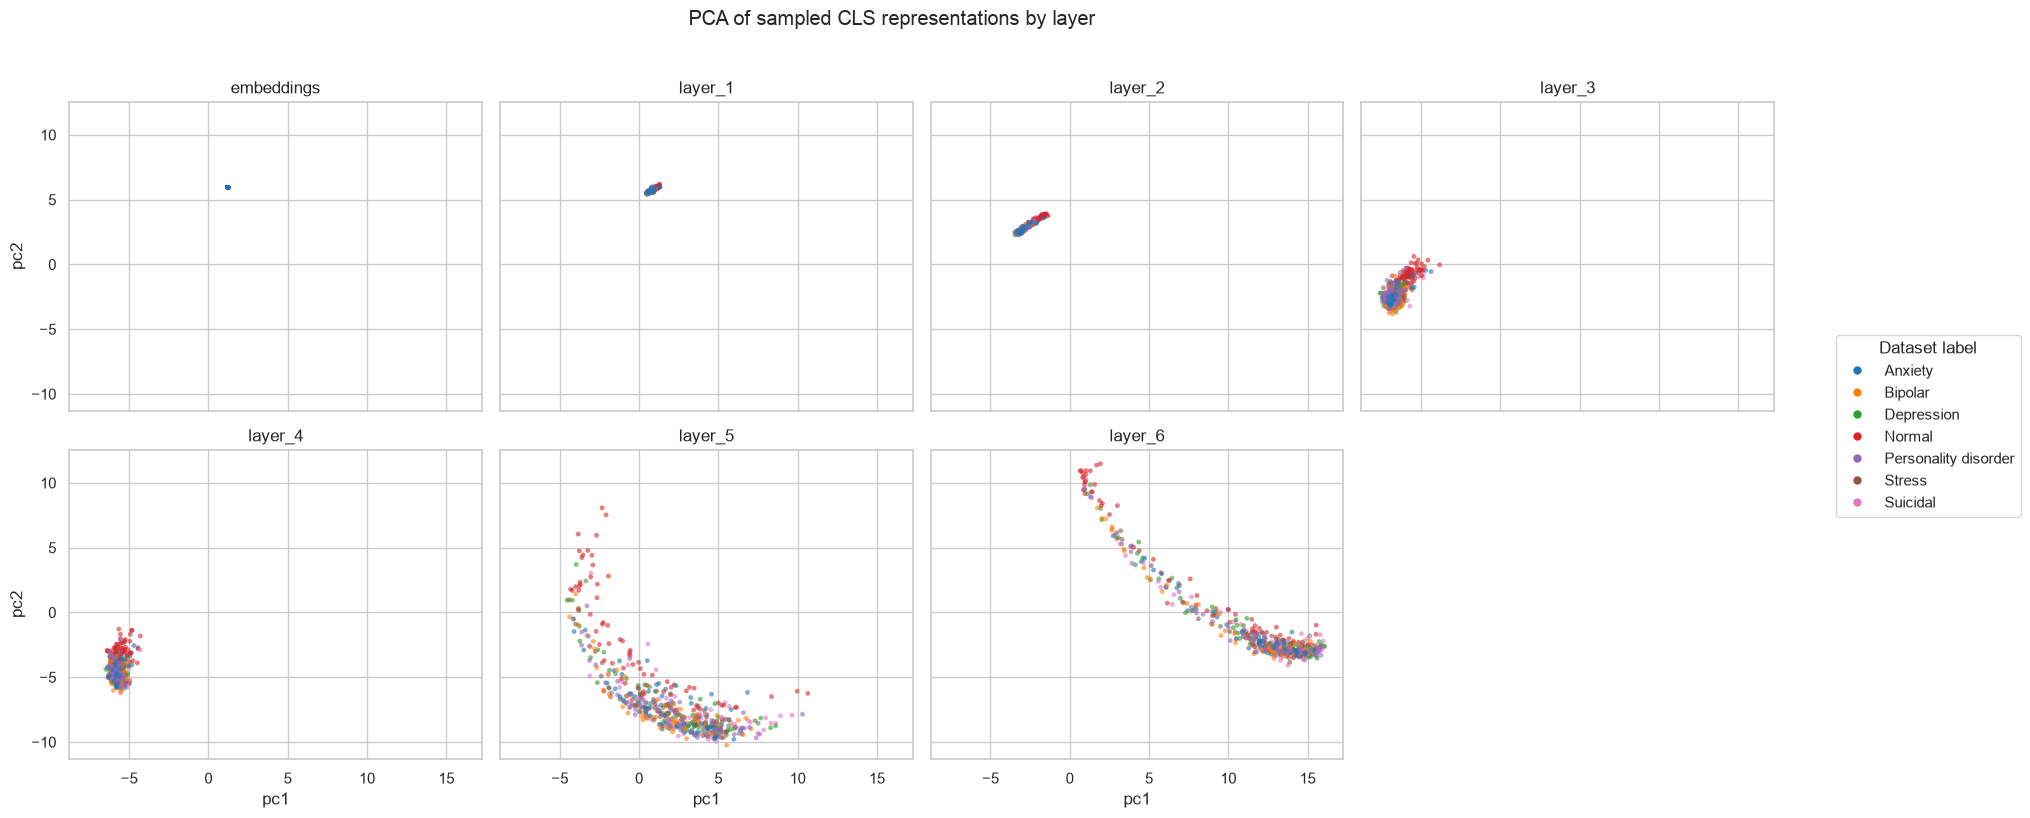

In [9]:
n_sample, n_layers, hidden_dim = sample_layer_vectors.shape
flat_vectors = sample_layer_vectors.reshape(n_sample * n_layers, hidden_dim)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(flat_vectors)

plot_df = pd.DataFrame(coords, columns=["pc1", "pc2"])
plot_df["layer"] = np.tile(layer_names, n_sample)
plot_df["row_id"] = np.repeat(sample_meta["row_id"].to_numpy(), n_layers)
plot_df["status"] = np.repeat(sample_meta["status"].to_numpy(), n_layers)

print("Explained variance ratio:", pca.explained_variance_ratio_)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.ravel()
palette = dict(zip(sorted(data_df["status"].unique()), sns.color_palette("tab10", n_colors=data_df["status"].nunique())))

for ax, layer_name in zip(axes, layer_names):
    layer_df = plot_df[plot_df["layer"] == layer_name]
    sns.scatterplot(
        data=layer_df,
        x="pc1",
        y="pc2",
        hue="status",
        palette=palette,
        s=12,
        alpha=0.6,
        linewidth=0,
        legend=False,
        ax=ax,
    )
    ax.set_title(layer_name)

axes[-1].axis("off")
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=status, markerfacecolor=color, markersize=7)
    for status, color in palette.items()
]
fig.legend(handles=legend_handles, title="Dataset label", bbox_to_anchor=(1.02, 0.5), loc="center left")
fig.suptitle("PCA of sampled CLS representations by layer", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pca_cls_representations_by_layer.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Linear probe: how separable are the dataset labels at each layer?

A linear probe trains a small logistic regression model on frozen DistilBERT `[CLS]` vectors from one layer at a time. This does not fine-tune DistilBERT. It estimates how much mental-health status information is linearly accessible from each layer's representation.

,layer,accuracy,macro_f1
0,embeddings,0.140625,0.035225
1,layer_1,0.562500,0.560780
2,layer_2,0.546875,0.549202
3,layer_3,0.554688,0.552120
4,layer_4,0.539062,0.534045
5,layer_5,0.578125,0.574711
6,layer_6,0.523438,0.516535


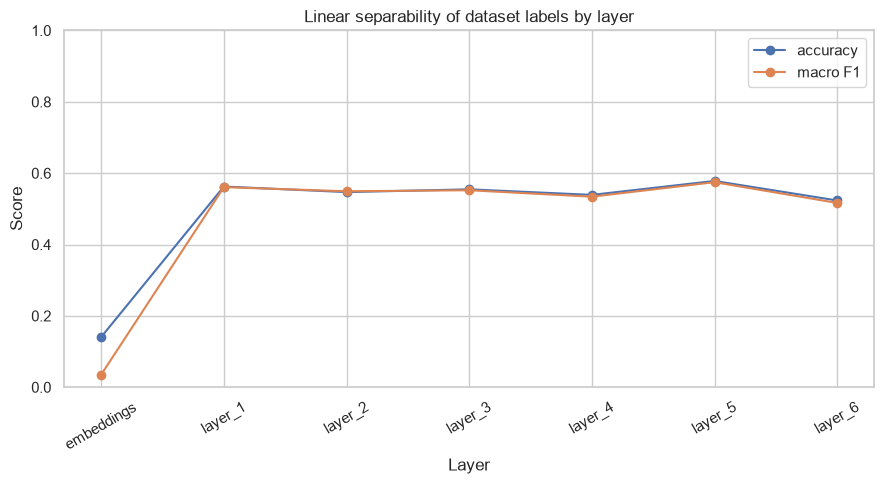

In [10]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(sample_meta["status"])
train_idx, test_idx = train_test_split(
    np.arange(len(sample_meta)),
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

probe_records = []
for layer_idx, layer_name in enumerate(layer_names):
    X = sample_layer_vectors[:, layer_idx, :]
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    )
    clf.fit(X[train_idx], y[train_idx])
    pred = clf.predict(X[test_idx])
    probe_records.append(
        {
            "layer": layer_name,
            "accuracy": accuracy_score(y[test_idx], pred),
            "macro_f1": f1_score(y[test_idx], pred, average="macro"),
        }
    )

probe_df = pd.DataFrame(probe_records)
probe_df.to_csv(OUTPUT_DIR / "linear_probe_by_layer.csv", index=False)
display(probe_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(probe_df["layer"], probe_df["accuracy"], marker="o", label="accuracy")
ax.plot(probe_df["layer"], probe_df["macro_f1"], marker="o", label="macro F1")
ax.set_title("Linear separability of dataset labels by layer")
ax.set_xlabel("Layer")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "linear_probe_by_layer.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Inspect individual rows

This makes the layer-by-layer sentiment-head trajectory concrete for a single dataset row.

row_id: 22022
dataset label: Suicidal
statement: sometimes i feel fine and then everything somehow comes crashing down and i just want to be dead all over againive no motivation to do anything anymore, no friends,no family,no talents, absolutely nothing. I am a waste of space, i have not been able to do anything in days, i cannot eat and cannot sleep anymore and i honestly feel like I am already dead it does not get better


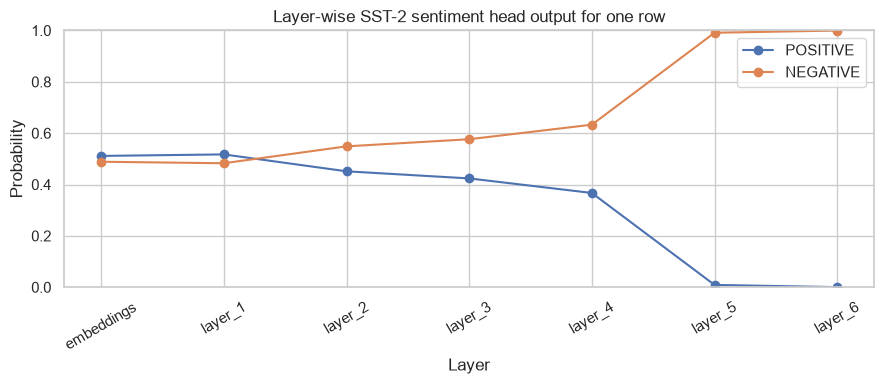

In [11]:
def inspect_row(row_id=None):
    if row_id is None:
        row_id = int(layer_metrics.sample(1, random_state=RANDOM_STATE)["row_id"].iloc[0])
    row = data_df.loc[data_df["row_id"] == row_id].iloc[0]
    metrics_row = layer_metrics.loc[layer_metrics["row_id"] == row_id].iloc[0]

    pos_values = [metrics_row[f"positive_{name}"] for name in layer_names]
    neg_values = [metrics_row[f"negative_{name}"] for name in layer_names]

    print(f"row_id: {row_id}")
    print(f"dataset label: {row['status']}")
    print(f"statement: {row['statement']}")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(layer_names, pos_values, marker="o", label="POSITIVE")
    ax.plot(layer_names, neg_values, marker="o", label="NEGATIVE")
    ax.set_title("Layer-wise SST-2 sentiment head output for one row")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
    fig.tight_layout()
    plt.show()


inspect_row()

## 11. Rows with the largest sentiment shift

These examples have the largest absolute change between the embedding-level positive probability and the final-layer positive probability.

In [12]:
shift_df = layer_metrics[["row_id", "status", "statement_preview", "positive_embeddings", "positive_layer_6"]].copy()
shift_df["positive_shift_final_minus_embedding"] = shift_df["positive_layer_6"] - shift_df["positive_embeddings"]
shift_df["abs_shift"] = shift_df["positive_shift_final_minus_embedding"].abs()

display(
    shift_df.sort_values("abs_shift", ascending=False)
    .head(15)
    .drop(columns="abs_shift")
)

,row_id,status,statement_preview,positive_embeddings,positive_layer_6,positive_shift_final_minus_embedding
153,26819,Suicidal,Or cared about or at least to know more like 5...,0.511337,0.000190,-0.511147
158,27267,Depression,I have come to the realization that no one rea...,0.511337,0.000200,-0.511138
30,5859,Normal,Tired.,0.511337,0.000214,-0.511123
423,50546,Personality disorder,Completely shut down when I know something unc...,0.511337,0.000222,-0.511115
484,51442,Personality disorder,Completely shut down when I know something unc...,0.511337,0.000222,-0.511115
140,25336,Depression,I was finally doing better and concentrating o...,0.511337,0.000234,-0.511103
335,46251,Bipolar,money Have spent over $7000 in the last few mo...,0.511337,0.000261,-0.511076
124,22022,Suicidal,sometimes i feel fine and then everything some...,0.511337,0.000271,-0.511066
120,21210,Depression,I feel like I need to do something but I just ...,0.511337,0.000285,-0.511052
149,26454,Depression,laying here with my wrists cut open. strugglin...,0.511337,0.000297,-0.511040


## Saved outputs

This notebook writes analysis artifacts to `outputs/distilbert_layer_analysis/`:

- `all_rows_layer_sentiment_and_drift.csv`: layer-wise sentiment probabilities and representation drift for every processed row.
- `sample_cls_vectors_by_layer.npy`: sampled full `[CLS]` vectors, shaped `(sample_rows, 7, 768)` for the default DistilBERT model.
- `sample_rows.csv`: metadata for sampled rows.
- PNG plots for sentiment trajectories, drift, PCA, and linear probes.